In [56]:
# Pour éviter d'avoir à sauvegarder le fichier bibliothèque à chaque fois qu'on le modifie
%load_ext autoreload
%autoreload 2

from utils_energie import charger, tracer, tracer_semaine_type_mois, tracer_semaine_type_mois_filtre

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [151]:
# Chargement des données
Argile = "Courbes de charge Mines/Argile.xlsx"
Basalte = "Courbes de charge Mines/Basalte.xlsx"
Charbon = "Courbes de charge Mines/Charbon.xlsx"
Diamant = "Courbes de charge Mines/Diamant.xlsx"
Emeraude = "Courbes de charge Mines/Emeraude.xlsx"
Filon = "Courbes de charge Mines/Filon.xlsx"
Granite = "Courbes de charge Mines/Granite.xlsx"
Houille = "Courbes de charge Mines/Houille.xlsx"
Ivoire = "Courbes de charge Mines/Ivoire.xlsx"
Jade = "Courbes de charge Mines/Jade.xlsx"
Kiwi = "Courbes de charge Mines/Kiwi.xlsx"
Lave = "Courbes de charge Mines/Lave.xlsx"

dataset_name = Filon #à modifier avec celui qu'on veut afficher

df = charger(dataset_name)

if not(dataset_name == Argile or dataset_name == Basalte or dataset_name == Charbon or dataset_name == Emeraude):
    df=df*1000

# Affichage rapide pour vérifier
display(df.head())

,kW
2024-06-01 00:00:00,4.24
2024-06-01 00:30:00,4.24
2024-06-01 01:00:00,4.24
2024-06-01 01:30:00,4.24
2024-06-01 02:00:00,4.24


**Utilisation de la fonction tracer:**
Appeler tracer(df_energie, echelle="...", debut="...") en modifiant simplement le paramètre echelle ("jour", "semaine", "mois", "annee") pour ajuster le zoom temporel, et optionnellement debut ("AAAA-MM-JJ") pour cibler une date précise.

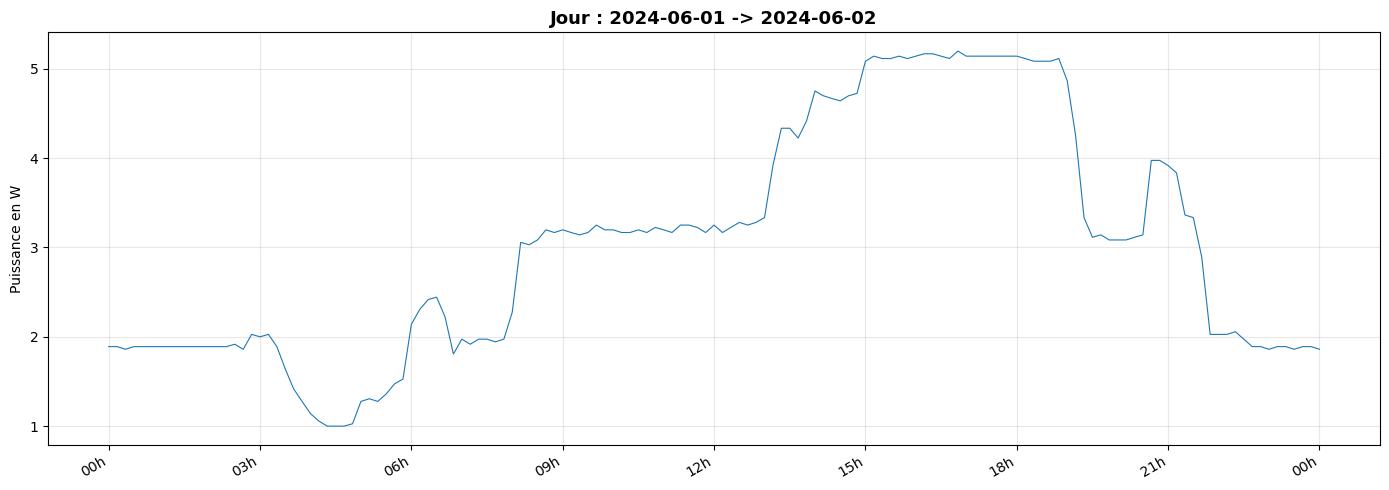

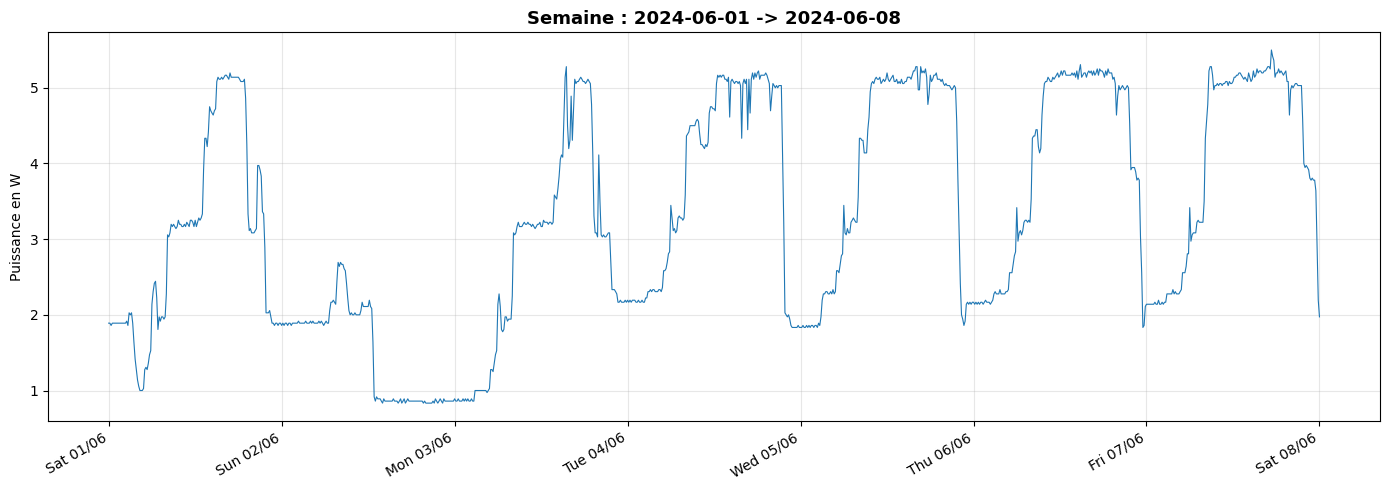

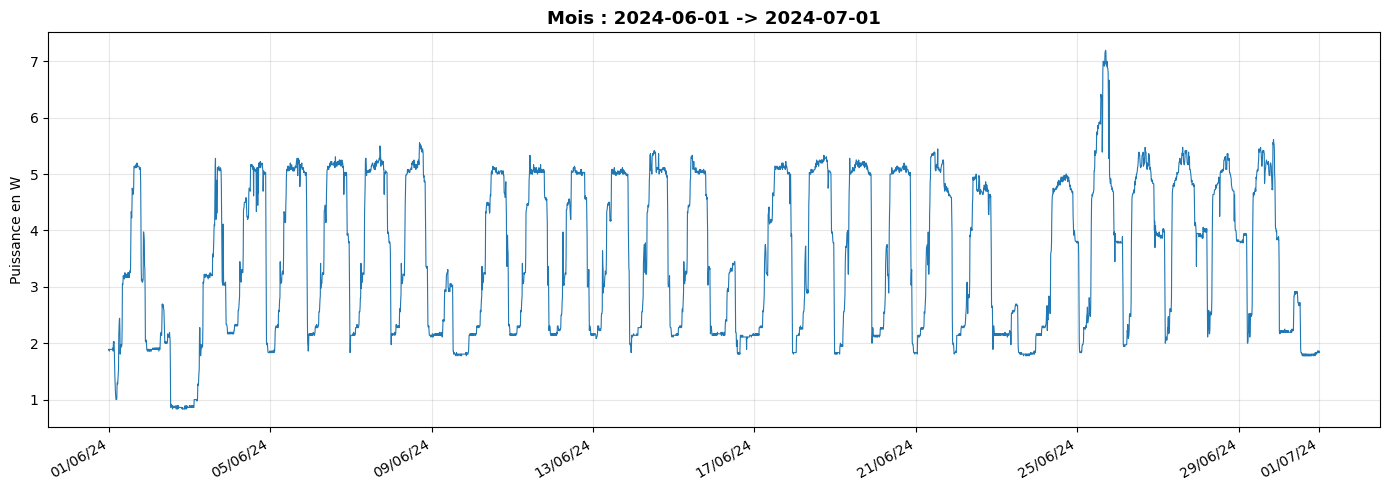

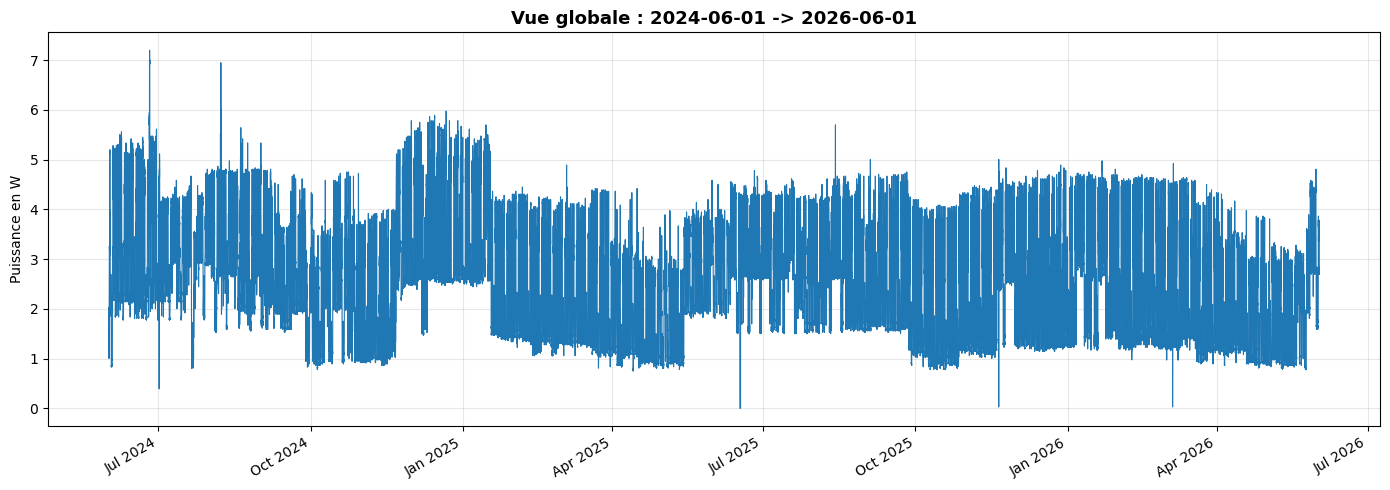

In [58]:
tracer(df, echelle="jour")
tracer(df, echelle="semaine")
tracer(df, echelle="mois")
tracer(df)

**Utilisation de la fonction tracer_semaine_type_mois:** Appeler tracer_semaine_type_mois(df_energie, mois=5) pour générer le graphique de la consommation moyenne d'une semaine type pour le mois choisi sur les 12 derniers mois. Si les données sont trop bruitées, préférez tracer_semaine_type_mois_filtre(df_energie, mois=5, span=7), qui applique un filtre passe-bas pour lisser la courbe et faire ressortir la tendance de fond. Le paramètre optionnel span vous permet d'ajuster facilement la force de ce lissage.

In [59]:
a = tracer_semaine_type_mois(df, mois=1)
b = tracer_semaine_type_mois(df, mois=6)
c = tracer_semaine_type_mois(df, mois=10)

In [61]:
a = tracer_semaine_type_mois(df, mois=6)
b = tracer_semaine_type_mois_filtre(df, span=20, mois=6)
#tracer(df, echelle="semaine", debut = "2023-06-05")

In [62]:
import numpy as np
import matplotlib.pyplot as plt

In [110]:
df_lisse = df.copy()
cols_num = df.select_dtypes(include=[np.number]).columns
df_lisse[cols_num] = df_lisse[cols_num].ewm(span=7, adjust=False).mean()

In [152]:
jours =[]
semaines = []
mois = []
annees = []

for i in range(int(len(df)/(144))):
    jours.append(df.iloc[144*i:(i+1)*144])
    
for i in range(int(len(df_lisse)/(144*7))):
    semaines.append(df_lisse.iloc[144*7*i:(i+1)*144*7])

for i in range(int(len(df_lisse)/(144*7*4))):
    mois.append(df_lisse.iloc[144*7*4*i:(i+1)*144*7*4])
 
for i in range(int(len(df_lisse)/(144*7*4*12))):
    annees.append(df_lisse.iloc[144*7*4*12*i:(i+1)*144*7*4*12])

semainesfft = []
moisfft = []
anneesfft = []
for i in range(len(semaines)):
    semainesfft.append(np.fft.fft(semaines[i]))

for i in range(len(mois)):
    moisfft.append(np.fft.fft(mois[i]))

for i in range(len(annees)):
    anneesfft.append(np.fft.fft(annees[i]))

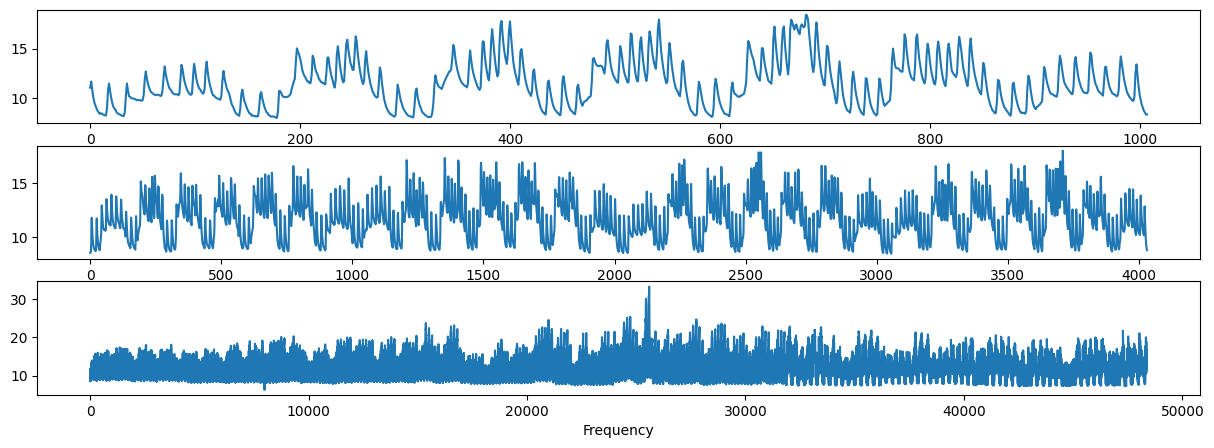

In [118]:
f1 = semainesfft[6]
f2 = moisfft[0]
f3 = anneesfft[0]

# Frequency shift
freqs1 = np.arange(f1.size//2)
freqs1 = np.concatenate((freqs1, -freqs1[::-1]))

freqs2 = np.arange(f2.size//2)
freqs2 = np.concatenate((freqs2, -freqs2[::-1]))

freqs3 = np.arange(f3.size//2)
freqs3 = np.concatenate((freqs3, -freqs3[::-1]))

# Display
plt.figure(figsize = (15, 5))
plt.subplot(3, 1, 1)
plt.plot(np.abs(f1))
plt.xlabel('Frequency')

plt.subplot(3, 1, 2)
plt.plot(np.abs(f2))
plt.xlabel('Frequency')

plt.subplot(3, 1, 3)
plt.plot(np.abs(f3))
plt.xlabel('Frequency') 
plt.show()

In [141]:
from sklearn.cluster import KMeans

In [154]:
df.index

DatetimeIndex(['2024-06-01 00:00:00', '2024-06-01 00:30:00',
               '2024-06-01 01:00:00', '2024-06-01 01:30:00',
               '2024-06-01 02:00:00', '2024-06-01 02:30:00',
               '2024-06-01 03:00:00', '2024-06-01 03:30:00',
               '2024-06-01 04:00:00', '2024-06-01 04:30:00',
               ...
               '2026-06-01 19:00:00', '2026-06-01 19:30:00',
               '2026-06-01 20:00:00', '2026-06-01 20:30:00',
               '2026-06-01 21:00:00', '2026-06-01 21:30:00',
               '2026-06-01 22:00:00', '2026-06-01 22:30:00',
               '2026-06-01 23:00:00', '2026-06-01 23:30:00'],
              dtype='datetime64[ns]', length=34710, freq=None)

In [155]:
jours_classe = []
t0 = df.index[0]

for i in range(int(len(df)/(144))):
    jour = []
    j = 144*i
    while j < (i+1)*144:
        jour.append(df.iloc[j].loc['kW'])
        j+=1
    jours_classe.append(jour)

nb_etats = 3
kmeans = KMeans(n_clusters=nb_etats, random_state=42, n_init=10)
labels = kmeans.fit_predict(jours_classe)


c:\miniconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [148]:
print(0 in labels)

True


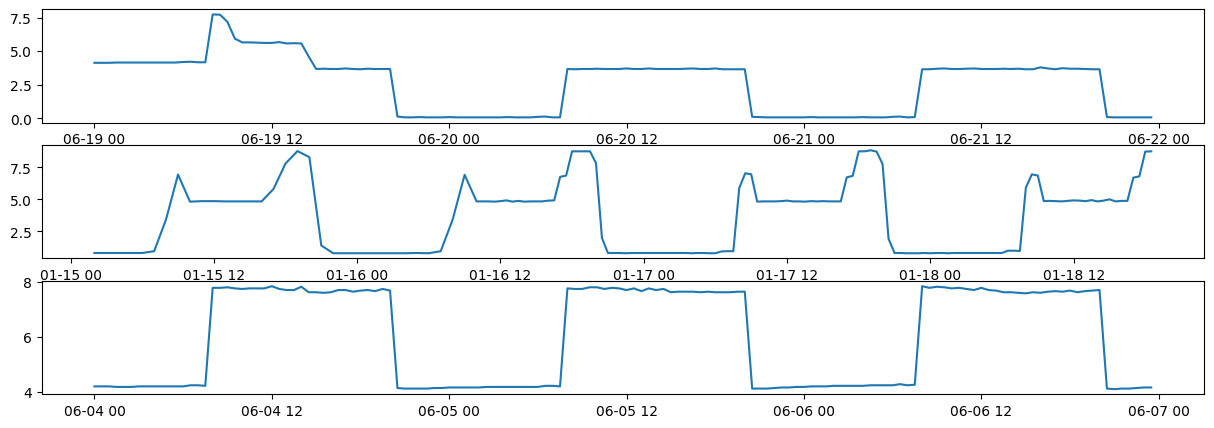

In [156]:
found1,found2,found3 = False, False, False
i=0
while not found1 :
    if labels[i] == 0:
        jours1 = jours[i]
        found1 = True
        i=0
    i+=1

while not found2 :
    if labels[i] == 1:
        jours2 = jours[i]
        found2 = True
        i=0
    i+=1

while not found3 :
    if labels[i] == 2:
        jours3 = jours[i]
        found3 = True
        i=0
    i+=1

plt.figure(figsize = (15, 5))
plt.subplot(3, 1, 1)
plt.plot(jours1)

plt.subplot(3, 1, 2)
plt.plot(jours2)

plt.subplot(3, 1, 3)
plt.plot(jours3)
plt.show()